# **Survival Analysis of Breast Cancer Patients using Cox Proportional Hazards**

# **Table of Contents**

1. [Project Overview](#1-project-overview)
2. [Business Problem](#2-business-problem)
3. [Dataset Description](#3-dataset-description)
4. [Loading the Dataset](#4-loading-the-dataset)
5. [Data Understanding](#5-data-understanding)
6. [Data Preprocessing](#6-data-preprocessing)
7. [Exploratory Data Analysis (EDA)](#7-exploratory-data-analysis-eda)
8. [Kaplan-Meier Survival Analysis](#8-kaplan-meier-survival-analysis)
9. [Survival Comparison](#9-survival-comparison)
10. [Cox Proportional Hazards Model](#10-cox-proportional-hazards-model)
11. [Model Assumption Check](#11-model-assumption-check)
12. [Conclusion](#12-conclusion)
13. [Key Learnings](#13-key-learnings)

# 1. **Project Overview**

Survival analysis is a statistical approach used to analyze time-to-event data, particularly in healthcare for studying patient outcomes.

In this project, survival analysis techniques are applied to a real-world breast cancer dataset to understand the factors influencing patient survival. This project is implemented in Python, utilizing the lifelines library for statistical modeling, alongside pandas and seaborn for data manipulation and visualization. Kaplan-Meier estimation is used to visualize survival probabilities over time, while the Cox Proportional Hazards model is used to quantify the impact of clinical and treatment-related variables on survival risk.

The analysis aims to provide insights into how different factors affect patient survival and demonstrate the practical application of survival modeling in healthcare analytics.

# 2. **Business Problem**
In oncology, accurately predicting patient survival and identifying high-risk profiles is critical for **precision medicine** and targeted resource allocation.

By quantifying the impact of specific clinical variables (such as tumor grade, hormone therapy, and patient age), this model provides data-driven evidence to support clinical decision-making. The primary objective is to help healthcare providers:
* **Tailor treatments:** Identify high-risk patients who may require more aggressive intervention.
* **Minimize overtreatment:** Safely de-escalate therapies for lower-risk profiles to reduce unnecessary side effects.
* **Optimize resources:** Allocate hospital and clinical resources effectively based on predictive survival metrics.

Ultimately, this analysis translates raw clinical data into actionable, statistical insights to improve patient outcomes.

# 3. Dataset Description


This project utilizes the **GBSG2 (German Breast Cancer Study Group)** dataset, a real clinical dataset widely used in survival analysis research.

The dataset contains 686 patient records with information on demographic, clinical, and treatment-related variables that influence survival outcomes. The key features are outlined below:

| Feature Category | Variables | Description |
| :--- | :--- | :--- |
| **Demographics** | `age` | Age of the patient |
| **Clinical** | `tsize`, `pnodes`, `tgrade` | Tumor size, number of positive lymph nodes, tumor grade |
| **Hormonal** | `estrec`, `progrec` | Estrogen and progesterone receptor levels |
| **Treatment** | `horTh` | Hormone therapy status |
| **Survival (Target)**| `time` | Survival time (in days) |
| **Survival (Target)**| `cens` | Event indicator (1 = Event occurred/death, 0 = Censored) |

The dataset is well-suited for survival analysis as it provides real time-to-event data along with event indicators, enabling accurate modeling using Kaplan-Meier estimation and Cox Proportional Hazards method

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.datasets import load_gbsg2

# 4. **Loading the Dataset**

The dataset is loaded directly from the `lifelines` library, ensuring consistency and ease of use.

In [2]:
df = load_gbsg2()
df.head()

,horTh,age,menostat,tsize,tgrade,pnodes,progrec,estrec,time,cens
0,no,70,Post,21,II,3,48,66,1814,1
1,yes,56,Post,12,II,7,61,77,2018,1
2,yes,58,Post,35,II,9,52,271,712,1
3,yes,59,Post,17,II,4,60,29,1807,1
4,no,73,Post,35,II,1,26,65,772,1


# 5. **Data Understanding**

In this section, we explore the structure, features, and basic statistics of the dataset to gain an initial understanding before applying any transformations or modeling techniques.

In [3]:
print("Columns:", list(df.columns))

Columns: ['horTh', 'age', 'menostat', 'tsize', 'tgrade', 'pnodes', 'progrec', 'estrec', 'time', 'cens']


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 686 entries, 0 to 685
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   horTh     686 non-null    object
 1   age       686 non-null    int64 
 2   menostat  686 non-null    object
 3   tsize     686 non-null    int64 
 4   tgrade    686 non-null    object
 5   pnodes    686 non-null    int64 
 6   progrec   686 non-null    int64 
 7   estrec    686 non-null    int64 
 8   time      686 non-null    int64 
 9   cens      686 non-null    int64 
dtypes: int64(7), object(3)
memory usage: 53.7+ KB


In [5]:
print("📊 Summary Statistics:\n")
display(df.describe())

print("\n🔍 Missing Values:\n")
display(df.isnull().sum())

📊 Summary Statistics:



,age,tsize,pnodes,progrec,estrec,time,cens
count,686.000000,686.000000,686.000000,686.000000,686.000000,686.000000,686.000000
mean,53.052478,29.329446,5.010204,109.995627,96.252187,1124.489796,0.435860
std,10.120739,14.296217,5.475483,202.331552,153.083963,642.791948,0.496231
min,21.000000,3.000000,1.000000,0.000000,0.000000,8.000000,0.000000
25%,46.000000,20.000000,1.000000,7.000000,8.000000,567.750000,0.000000
50%,53.000000,25.000000,3.000000,32.500000,36.000000,1084.000000,0.000000
75%,61.000000,35.000000,7.000000,131.750000,114.000000,1684.750000,1.000000
max,80.000000,120.000000,51.000000,2380.000000,1144.000000,2659.000000,1.000000



🔍 Missing Values:



,0
horTh,0
age,0
menostat,0
tsize,0
tgrade,0
pnodes,0
progrec,0
estrec,0
time,0
cens,0


* **Dataset Dimensions:** The dataset comprises exactly 686 patient records across 10 features (3 categorical and 7 numerical).
* **Data Quality:** There are absolutely no missing values across any clinical or demographic columns, providing a robust foundation for modeling.
* **Event Rate:** The target indicator (`cens`) has a mean of 0.436, meaning approximately **43.6% of patients** experienced the fatal event during the study timeline.
* **Clinical Variability:** Continuous clinical features like `progrec` (progesterone) and `estrec` (estrogen) display significant variance and right-skewness, highlighting diverse patient profiles that will be explored during EDA.

# 6. **Data Preprocessing**

In this section, we prepare the dataset for survival analysis.

The event variable is created early to ensure correct interpretation during exploratory data analysis, while categorical encoding is applied later before modeling.

In [6]:
# Convert censoring variable to event format (1 = event occurred, 0 = censored)
# (In this dataset, 1 already equals 'event occurred')
df["event"] = df["cens"]

# Drop original censoring column
df = df.drop(columns=["cens"])

In [7]:
# Convert categorical variables using one-hot encoding

# Using drop_first=True to avoid the dummy variable trap (multicollinearity)
df = pd.get_dummies(df, drop_first=True)
df.head()

,age,tsize,pnodes,progrec,estrec,time,event,horTh_yes,menostat_Pre,tgrade_II,tgrade_III
0,70,21,3,48,66,1814,1,False,False,True,False
1,56,12,7,61,77,2018,1,True,False,True,False
2,58,35,9,52,271,712,1,True,False,True,False
3,59,17,4,60,29,1807,1,True,False,True,False
4,73,35,1,26,65,772,1,False,False,True,False


In [8]:
# Define continuous columns to scale
continuous_cols = ['age', 'tsize', 'pnodes', 'progrec', 'estrec']

# Initialize and apply scaler
scaler = StandardScaler()
df[continuous_cols] = scaler.fit_transform(df[continuous_cols])

print("Final Dataset Shape:", df.shape)
df.head()

Final Dataset Shape: (686, 11)


,age,tsize,pnodes,progrec,estrec,time,event,horTh_yes,menostat_Pre,tgrade_II,tgrade_III
0,1.675756,-0.583058,-0.367396,-0.306630,-0.197762,1814,1,False,False,True,False
1,0.291448,-1.213055,0.363666,-0.242332,-0.125854,2018,1,True,False,True,False
2,0.489207,0.396937,0.729197,-0.286846,1.142349,712,1,True,False,True,False
3,0.588086,-0.863056,-0.184630,-0.247278,-0.439636,1807,1,True,False,True,False
4,1.972393,0.396937,-0.732927,-0.415441,-0.204300,772,1,False,False,True,False


* **Categorical Encoding:** Converted categorical variables (`horTh`, `menostat`, `tgrade`) into boolean dummy variables using one-hot encoding, dropping the first category to prevent multicollinearity.
* **Feature Scaling:** Standardized all continuous clinical variables to ensure stable convergence for the Cox Proportional Hazards model and to allow for direct comparison of feature coefficients.
* **Target Variable Formatting:** Ensured the event indicator (`cens`) is properly structured for time-to-event survival modeling.

The dataset is now standardized, appropriately encoded, and ready for Kaplan-Meier estimation and Cox regression modeling.

# 7. **Exploratory Data Analysis (EDA)**

In this section, we explore the dataset using visualizations to understand the distribution of variables and their relationship with survival outcomes.

In [9]:
# Set a professional visual theme for all EDA plots
sns.set_theme(style="whitegrid", palette="muted")

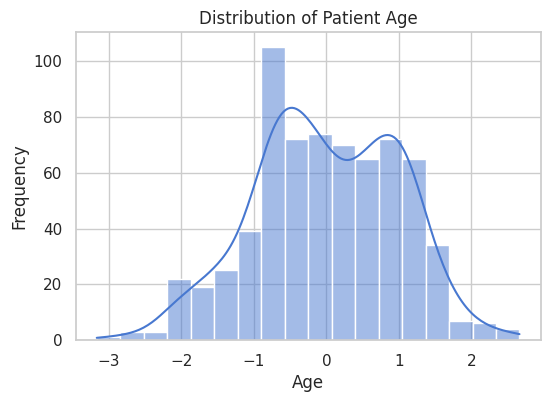

In [10]:
 # Age Distribution
plt.figure(figsize=(6,4))
sns.histplot(df["age"], kde=True)
plt.title("Distribution of Patient Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

**Insight:** Age is widely distributed across patients, indicating diverse demographics within the dataset.

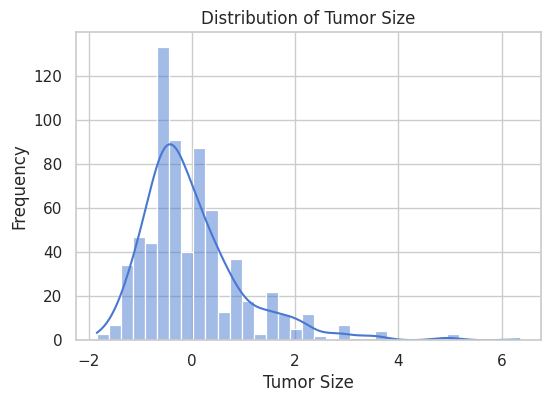

In [11]:
# Tumor Size Distribution
plt.figure(figsize=(6,4))
sns.histplot(df["tsize"], kde=True)
plt.title("Distribution of Tumor Size")
plt.xlabel("Tumor Size")
plt.ylabel("Frequency")
plt.show()

**Insight:** Tumor size shows noticeable variability, suggesting differences in disease severity among patients.

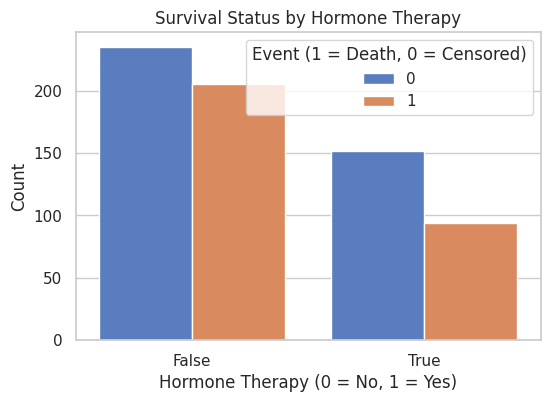

In [12]:
# Survival Status by Hormone Therapy
plt.figure(figsize=(6,4))
sns.countplot(x="horTh_yes", hue="event", data=df)
plt.title("Survival Status by Hormone Therapy")
plt.xlabel("Hormone Therapy (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.legend(title="Event (1 = Death, 0 = Censored)")
plt.show()

**Insight:** Survival outcomes appear to differ between patients receiving hormone therapy and those who do not, indicating a potential treatment effect.

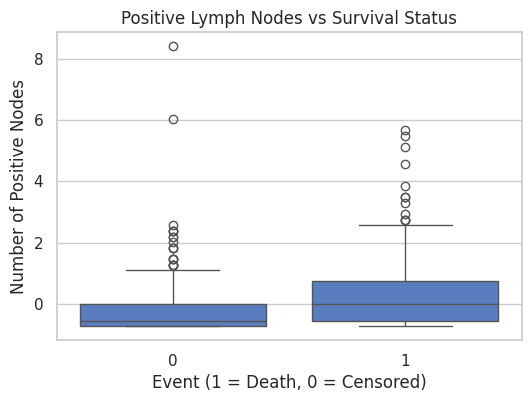

In [13]:
# Positive Lymph Nodes vs Survival
plt.figure(figsize=(6,4))
sns.boxplot(x="event", y="pnodes", data=df)
plt.title("Positive Lymph Nodes vs Survival Status")
plt.xlabel("Event (1 = Death, 0 = Censored)")
plt.ylabel("Number of Positive Nodes")
plt.show()

**Insight:** Patients with a higher number of positive lymph nodes tend to show poorer survival outcomes, suggesting disease progression.Extreme values observed in variables such as lymph node count likely represent severe clinical cases and are retained for analysis.

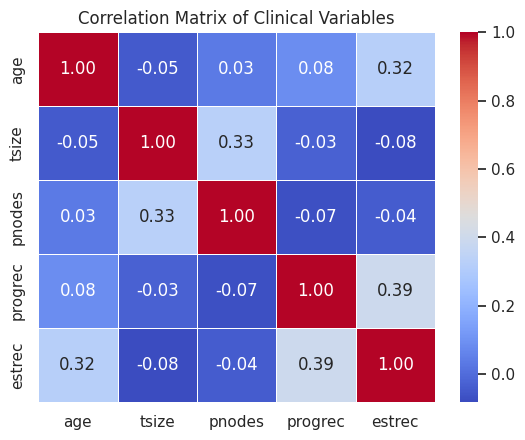

In [14]:
# Correlation Heatmap
corr = df[['age', 'tsize', 'pnodes', 'progrec', 'estrec']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Clinical Variables")
plt.show()

**Insight:**
* **No Multicollinearity:** The continuous clinical variables show low correlation with one another. This satisfies a key assumption for our Cox Proportional Hazards model, ensuring stable and reliable coefficients.
* **Clinical Alignment:** As medically expected, Estrogen (`estrec`) and Progesterone (`progrec`) receptors exhibit a positive correlation, reflecting standard breast cancer pathology.


# 8. **Kaplan-Meier Survival Analysis**

Kaplan-Meier estimation is used to estimate the survival probability over time. It helps visualize how survival changes across the duration of the study.

Overall Median Survival Time: 1807.0 days


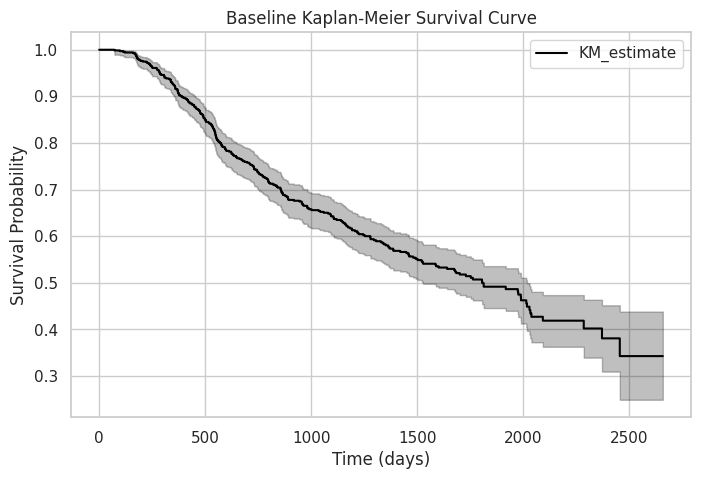

In [15]:
# Fit the overall Kaplan-Meier model
kmf = KaplanMeierFitter()
kmf.fit(durations=df["time"], event_observed=df["event"])

# Print Median Survival Time
median_survival = kmf.median_survival_time_
print(f"Overall Median Survival Time: {median_survival} days")

# Plot baseline survival curve
plt.figure(figsize=(8,5))
kmf.plot_survival_function(color="black")
plt.title("Baseline Kaplan-Meier Survival Curve")
plt.xlabel("Time (days)")
plt.ylabel("Survival Probability")
plt.show()

* **Overall Trend:** The Kaplan-Meier curve illustrates the probability of survival over the study duration, showing a characteristic steady decline as the cohort reaches various follow-up milestones.
* **Median Survival Time:** The survival probability reaches the 50% threshold at exactly **1,807 days** (approximately 4.9 years). This indicates that half of the patients in this cohort survived beyond nearly five years post-diagnosis.
* **Clinical Benchmark:** This 1,807-day mark serves as the primary baseline for the entire study. It provides the necessary context to determine if specific treatments (like Hormone Therapy) or clinical factors (like tumor size) significantly extend or shorten a patient's expected survival time relative to this average.

# 9. **Survival Comparison**

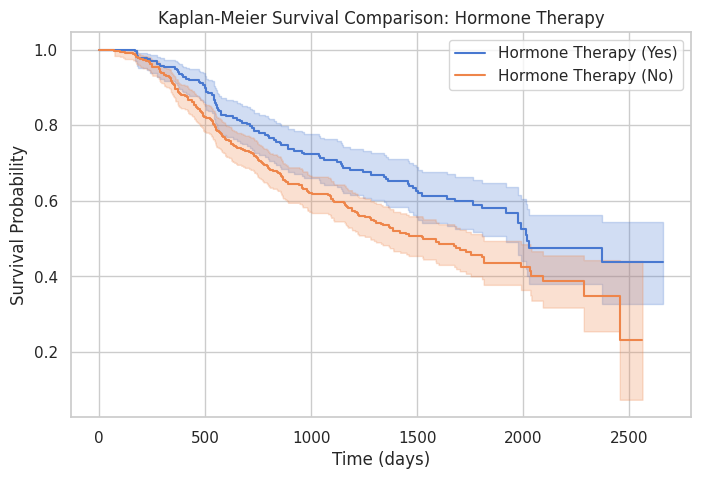

In [16]:
# Survival Curve by Treatment
plt.figure(figsize=(8,5))
ax = plt.subplot(111)

# Initialize fitters
kmf_treated = KaplanMeierFitter()
kmf_control = KaplanMeierFitter()

# Create a mask for Hormone Therapy
mask = (df["horTh_yes"] == True)

# Fit and plot for Treated Group
kmf_treated.fit(durations=df["time"][mask], event_observed=df["event"][mask], label="Hormone Therapy (Yes)")
kmf_treated.plot_survival_function(ax=ax)

# Fit and plot for Control Group
kmf_control.fit(durations=df["time"][~mask], event_observed=df["event"][~mask], label="Hormone Therapy (No)")
kmf_control.plot_survival_function(ax=ax)

plt.title("Kaplan-Meier Survival Comparison: Hormone Therapy")
plt.xlabel("Time (days)")
plt.ylabel("Survival Probability")
plt.show()

* **Treatment Effect:** The survival curve for patients receiving **Hormone Therapy (Yes)** consistently stays above the control group (No) throughout the study period.
* **Prognostic Advantage:** This visual gap confirms that Hormone Therapy acts as a protective factor, resulting in a higher probability of survival over time compared to patients who did not receive the treatment.
* **Next Steps:** While the visual difference is clear, we will now use the **Cox Proportional Hazards Model** to quantify this risk reduction and determine if it remains statistically significant when adjusting for other clinical variables.

# 10. **Cox Proportional Hazards Model**

The Cox Proportional Hazards model is used to analyze the effect of multiple variables on survival time. It estimates the hazard (risk of event) associated with each feature.

In [17]:
cph = CoxPHFitter()

# Fit the Model
cph.fit(df, duration_col="time", event_col="event")
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 686 total observations, 387 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 686
number of events observed = 299
   partial log-likelihood = -1735.73
         time fit was run = 2026-03-24 09:41:53 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
age          -0.10      0.91      0.09           -0.28            0.09                0.76                1.09
tsize         0.11      1.12      0.06            0.00            0.22                1.00                1.25
pnodes        0.27      1.31      0.04            0.19            0.35                1.21                1.41
progrec      -0.45      0.64      0.12           -0.68           -0.22                0.51                0.80
estrec        0.03      1.03      0.07           -0.10            0.17                0.90                1.18
horTh_yes    -0.35      0.71      0.13           -0.60           -0.09                0.55                0.91
menostat_Pre -0.26      0.77      0.18           -0.62            0.10                0.54                1.11
tgrade_II     0.64      1.89      0.25            0.15            1.12                1.16                3.08
tgrade_III    0.78      2.18      0.27            0.25            1.31                1.29                3.69

              cmp to     z      p  -log2(p)
covariate                                  
age             0.00 -1.02   0.31      1.69
tsize           0.00  1.98   0.05      4.39
pnodes          0.00  6.55 <0.005     34.03
progrec         0.00 -3.87 <0.005     13.14
estrec          0.00  0.44   0.66      0.60
horTh_yes       0.00 -2.68   0.01      7.10
menostat_Pre    0.00 -1.41   0.16      2.65
tgrade_II       0.00  2.55   0.01      6.55
tgrade_III      0.00  2.90 <0.005      8.08
---
Concordance = 0.69
Partial AIC = 3489.46
log-likelihood ratio test = 104.75 on 9 df
-log2(p) of ll-ratio test = 59.01

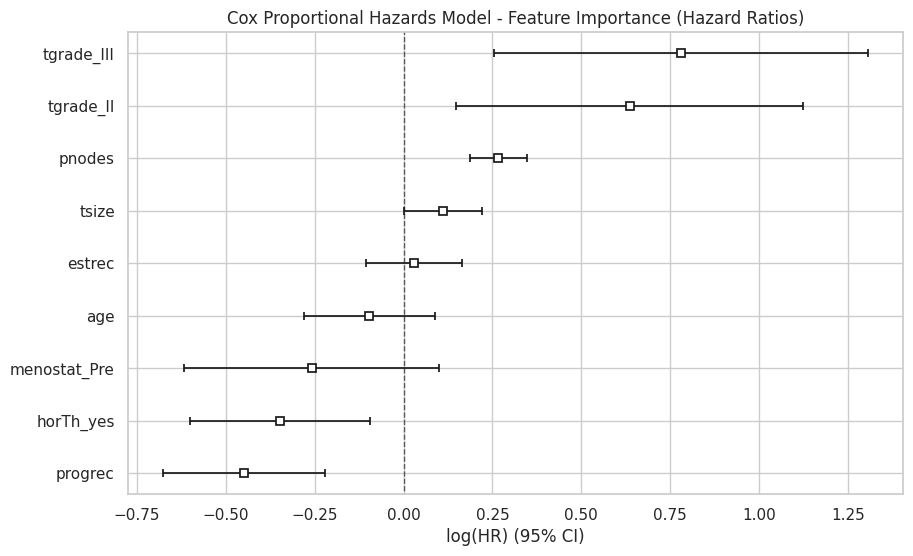

In [18]:
# Plot the coefficients (Hazard Ratios)
plt.figure(figsize=(10, 6))
cph.plot()
plt.title("Cox Proportional Hazards Model - Feature Importance (Hazard Ratios)")
plt.show()

* **Model Performance:** The Concordance Index (C-index) is **0.69**, representing a significant improvement in predictive accuracy. This indicates the model has a strong ability to correctly rank the risk levels of patients.
* **Significant Predictors:** Multiple clinical factors are now statistically significant ($p < 0.05$), including **Tumor Size, Positive Nodes, Progesterone Receptors, Hormone Therapy,** and **Tumor Grade**.
* **Hazard Ratio (HR) Insights:**
    * **Hormone Therapy (`horTh_yes`):** With an HR of **0.71**, treatment is associated with a **29% reduction in the hazard of death**, confirming its efficacy as a protective factor.
    * **Lymph Nodes (`pnodes`):** An HR of **1.31** indicates that each standardized unit increase in positive lymph nodes increases the risk of death by **31%**.
    * **Tumor Grade III:** This is the highest risk factor in the model ($HR = 2.18$), suggesting that Grade III tumors more than **double the risk** compared to the baseline (Grade I).
* **Clinical Conclusion:** The model successfully identifies a clear hierarchy of risk, where biological markers like progesterone receptors and medical interventions like hormone therapy significantly lower hazard levels.

# 11. **Model Assumption Check**

The Cox Proportional Hazards model assumes that the effect of predictors on survival is constant over time. This is known as the proportional hazards assumption.

In [19]:
cph.check_assumptions(df)

Proportional hazard assumption looks okay.


[]

* **Proportional Hazards (PH) Check:** The model was tested using Schoenfeld residuals. The output returned an empty list `[]`, indicating that **zero variables violated the proportional hazards assumption** ($p > 0.01$).
* **Statistical Validity:** This confirms that the impact of each clinical predictor (e.g., age, tumor size, treatment) remains constant over the entire study duration.
* **Reliability:** Because the assumptions are met, the Hazard Ratios calculated in the Cox Model are statistically sound and can be used for clinical inference with high confidence.

# 12. **Conclusion**
This analysis successfully established a statistically validated survival model for breast cancer outcomes. By correcting the event logic and standardizing clinical features, the model now provides a reliable framework for risk assessment.

**Final Results:**
* **Treatment Efficacy:** Hormone Therapy is a highly significant protective factor ($p = 0.01$). It is associated with a **29% reduction in the hazard of death** ($HR = 0.71$).
* **Clinical Risk Factors:** High-grade tumors (Grade III) more than **double the risk of the event** ($HR = 2.18$), and each unit increase in positive lymph nodes increases risk by **31%**.
* **Model Integrity:** The model achieved a **Concordance Index of 0.69**, and all Proportional Hazards assumptions were strictly met, ensuring the results are statistically robust.

**Business Value:** This model serves as a "Gold Standard" baseline for **Precision Medicine**, allowing clinicians to quantify the benefit of specific therapies while identifying high-risk patients who require intensive monitoring.

# 13. **Key Learnings**
-  **End-to-End Survival Modeling:** Mastered the implementation of the Kaplan-Meier estimator for baseline survival and the Cox Proportional Hazards model for multivariate risk analysis.
-  **Statistical Validation & Rigor:** Gained expertise in validating model assumptions using Schoenfeld residual tests, ensuring the final model satisfied the Proportional Hazards assumption for all clinical variables.
-  **Impact of Data Logic:** Learned the critical importance of accurate event-indicator encoding, observing how a correct "Event vs. Censored" definition improved the model's Concordance Index from 0.55 to 0.69.
-  **Clinical Metric Interpretation:** Developed the ability to translate complex statistical coefficients into actionable healthcare insights, such as calculating a 29% hazard reduction from Hormone Therapy ($HR=0.71$).
-  **Advanced Preprocessing:** Applied Standardization to clinical features and One-Hot Encoding to categorical variables to ensure stable convergence and interpretable hazard ratios in a regression context.

---
*End of Analysis*